In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading BindingDB (TgDHFR dataset)

In [3]:
bindingDB_df = pd.read_csv('BindingDB_TgDHFR.csv')
bindingDB_df.head(2)

,BindingDB Reactant_set_id,Smiles,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Primary ID of Target Chain.12,UniProt (SwissProt) Secondary ID(s) of Target Chain.12,UniProt (SwissProt) Alternative ID(s) of Target Chain.12,UniProt (TrEMBL) Submitted Name of Target Chain.12,UniProt (TrEMBL) Entry Name of Target Chain.12,UniProt (TrEMBL) Primary ID of Target Chain.12,UniProt (TrEMBL) Secondary ID(s) of Target Chain.12,UniProt (TrEMBL) Alternative ID(s) of Target Chain.12,Temp_C_float,pIC50 Value
0,32537,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,InChI=1S/C19H22N4O4/c1-26-15-9-12(6-4-3-5-7-16...,MDVRFMJVQMAYTM-UHFFFAOYSA-N,18223,"6-{3-[(2,4-diaminopyrimidin-5-yl)methyl]-4,5-d...",Bifunctional dihydrofolate reductase-thymidyla...,NaN,NaN,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.468521
1,32538,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,IEDVJHCEMCRBQM-UHFFFAOYSA-N,18069,"5-[(3,4,5-trimethoxyphenyl)methyl]pyrimidine-2...",Bifunctional dihydrofolate reductase-thymidyla...,NaN,NaN,2722.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.565112


In [5]:
bindingDB_df['PubChem CID'].nunique()

805

In [16]:
bd = bindingDB_df['PubChem CID'].unique()

In [17]:
len(bd)

805

In [6]:
bindingDB_df.shape

(805, 196)

In [94]:
bindingDB_df.columns.to_list()

['BindingDB Reactant_set_id',
 'Smiles',
 'Ligand InChI',
 'Ligand InChI Key',
 'BindingDB MonomerID',
 'BindingDB Ligand Name',
 'Target Name',
 'Target Source Organism According to Curator or DataSource',
 'Ki (nM)',
 'IC50 (nM)',
 'Kd (nM)',
 'EC50 (nM)',
 'kon (M-1-s-1)',
 'koff (s-1)',
 'pH',
 'Temp (C)',
 'Curation/DataSource',
 'Article DOI',
 'BindingDB Entry DOI',
 'PMID',
 'PubChem AID',
 'Patent Number',
 'Authors',
 'Institution',
 'Link to Ligand in BindingDB',
 'Link to Target in BindingDB',
 'Link to Ligand-Target Pair in BindingDB',
 'Ligand HET ID in PDB',
 'PDB ID(s) for Ligand-Target Complex',
 'PubChem CID',
 'PubChem SID',
 'ChEBI ID of Ligand',
 'ChEMBL ID of Ligand',
 'DrugBank ID of Ligand',
 'IUPHAR_GRAC ID of Ligand',
 'KEGG ID of Ligand',
 'ZINC ID of Ligand',
 'Number of Protein Chains in Target (>1 implies a multichain complex)',
 'BindingDB Target Chain Sequence',
 'PDB ID(s) of Target Chain',
 'UniProt (SwissProt) Recommended Name of Target Chain',
 'UniP

In [8]:
#Selecting necessary columns

bd_df = bindingDB_df[['PubChem CID','Smiles','IC50 (nM)', 'pIC50 Value']].copy()
bd_df.rename(columns={'IC50 (nM)': 'Standard Value', 'PubChem CID': 'cid'}, inplace=True)
bd_df.reset_index(drop=True, inplace=True)


In [9]:
bd_df.head()

,cid,Smiles,Standard Value,pIC50 Value
0,23647975.0,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.000,7.468521
1,5578.0,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.000,5.565112
2,54369.0,COc1ccc(OC)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,14.224,7.846978
3,6481073.0,COc1ccc(OCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,1.900,8.721246
4,6481074.0,COc1ccc(OCCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,2.300,8.638272


# 2. Reading ChMBL (TgDHFR dataset)

In [12]:
chmbl_df = pd.read_csv('V2-df_ic50_chmbl_CID_myFill.csv')
chmbl_df.head(2)

,Molecule ChEMBL ID,Smiles,Molecular Weight,AlogP,Standard Value,pIC50 Value,cid
0,CHEMBL85576,CCc1nc(N)nc(N)c1-c1ccc(Cl)c(/N=N/N(CCOC(=O)C(C...,496.02,5.22,660.000000,6.180456,11071072
1,CHEMBL141708,COc1ccc(/C=C/c2cnc3nc(N)nc(N)c3c2)cc1OC,323.36,2.38,1399.863333,5.853914,6474985


In [13]:
chmbl_df.shape

(758, 7)

In [14]:
chmbl_df['Smiles'].nunique()

758

In [15]:
chmbl_df['cid'].nunique()

758

In [18]:
che = chmbl_df['cid'].unique()

In [19]:
# Find the common elements and copy them to the list 'interfer'
interfer = [element for element in bd if element in che]

In [20]:
len(interfer)

686

In [21]:
#Selecting necessary columns

chmbl_df = chmbl_df[['cid','Smiles','Standard Value', 'pIC50 Value']].copy()
chmbl_df.reset_index(drop=True, inplace=True)

# 3. Concate two datasets: bd_df abd chmbl_df

In [22]:
# Concatenate the two DataFrames
combined_bd_chmbl = pd.concat([bd_df, chmbl_df], ignore_index=True)

# Display the first few rows of the combined DataFrame
combined_bd_chmbl.shape

(1563, 4)

# 4. Check for dublicates: using CID

In [24]:
# Check for dublicates:
# Identify and show all rows with duplicated 'CID' values
duplicates = combined_bd_chmbl[combined_bd_chmbl['cid'].duplicated(keep=False)]

# Display the rows with duplicate 'Smiles' values
duplicates.shape


(1372, 4)

In [25]:
duplicates

,cid,Smiles,Standard Value,pIC50 Value
1,5578.0,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.000000,5.565112
2,54369.0,COc1ccc(OC)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,14.224000,7.846978
3,6481073.0,COc1ccc(OCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,1.900000,8.721246
4,6481074.0,COc1ccc(OCCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,2.300000,8.638272
5,6481075.0,COc1ccc(OCCCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,2.000000,8.698970
...,...,...,...,...
1558,54369.0,COc1ccc(OC)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,13.488889,7.870024
1559,5583.0,COc1cc(NCc2ccc3nc(N)nc(N)c3c2C)cc(OC)c1OC,10.000000,8.000000
1560,5578.0,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2724.516129,5.564711
1561,4993.0,CCc1nc(N)nc(N)c1-c1ccc(Cl)cc1,314.083333,6.502955


In [26]:
# Group by 'PubChem CID' and then display the 'pH' and 'IC50 (nM)' for each group
grouped_dupl = combined_bd_chmbl.groupby('cid')[['Standard Value','pIC50 Value']]

# Convert to a list for display or further processing
grouped_dupl_list = grouped_dupl.apply(lambda x: x.reset_index(drop=True)).reset_index()

# Assuming 'level_1' is a column in grouped_dupl_list
sorted_grouped_dupl_list = grouped_dupl_list.sort_values(by='level_1', ascending=False)

# Display the result
grouped_dupl_list.head(20)

,cid,level_1,Standard Value,pIC50 Value
0,1405.0,0,360.000000,6.443697
1,1987.0,0,690.000000,6.161151
2,1987.0,1,690.000000,6.161151
3,3439.0,0,19800.000000,4.703335
4,3439.0,1,19800.000000,4.703335
5,4993.0,0,311.076923,6.507132
6,4993.0,1,314.083333,6.502955
7,5578.0,0,2722.000000,5.565112
8,5578.0,1,2724.516129,5.564711
9,5583.0,0,10.000000,8.000000


In [28]:
# Keep only the first occurrence of each duplicated 'Smiles'
combined_bd_chmbl_unique = combined_bd_chmbl.drop_duplicates(subset='cid', keep='first')

# Display the first few rows of the DataFrame
combined_bd_chmbl_unique.shape


(877, 4)

In [29]:
combined_bd_chmbl_unique['pIC50 Value'].isna().sum()

2

In [30]:
# dropped NaN from 'pIC50 Value'
combined_bd_chmbl_unique = combined_bd_chmbl_unique.dropna(subset=['pIC50 Value'])

# Reindex the DataFrame to reset the index
combined_bd_chmbl_unique.reset_index(drop=True, inplace=True)

In [31]:
#Save Combined databases BindingDB and ChMBL:

combined_bd_chmbl_unique.to_csv('V2-combined_bd_chmbl_unique.csv', index=False)

# 5. Target Transformations: IC50

## 5.1. Origibal IC50

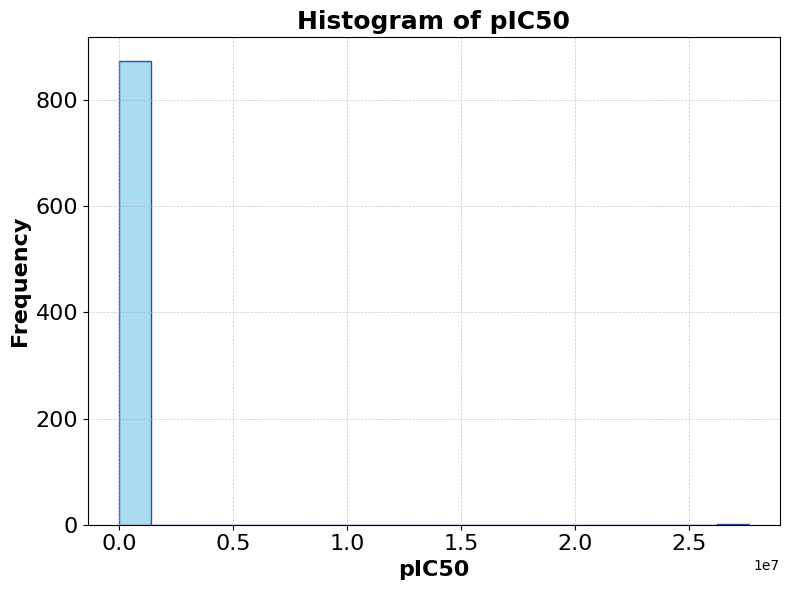

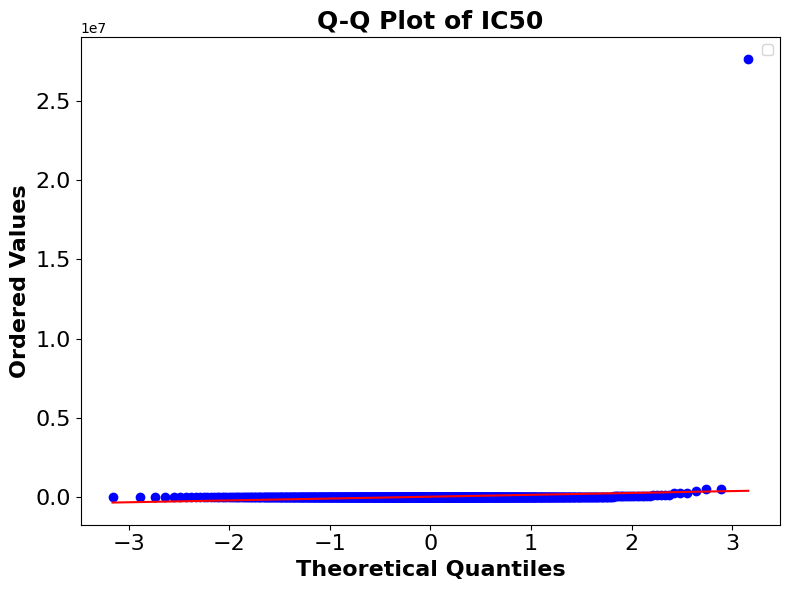

In [32]:
import matplotlib.pyplot as plt
from scipy import stats

# Sample data for log_target, replace this with your actual data
log_target = combined_bd_chmbl_unique['Standard Value']

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(log_target, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of pIC50', fontsize=18, weight='bold')
plt.xlabel('pIC50', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the histogram plot
plt.show()

# Q-Q plot of original data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(log_target, dist="norm", plot=plt)

# Add title and legend
plt.title('Q-Q Plot of IC50', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()

# 

In [33]:
# Shapiro-Wilk test
shapiro_stat, shapiro_p_value = stats.shapiro(combined_bd_chmbl_unique['Standard Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")

Shapiro-Wilk test statistic: 0.017869677059940914
Shapiro-Wilk test p-value: 1.0275635650572346e-54


## 5.2. Log-transformation: pIC50

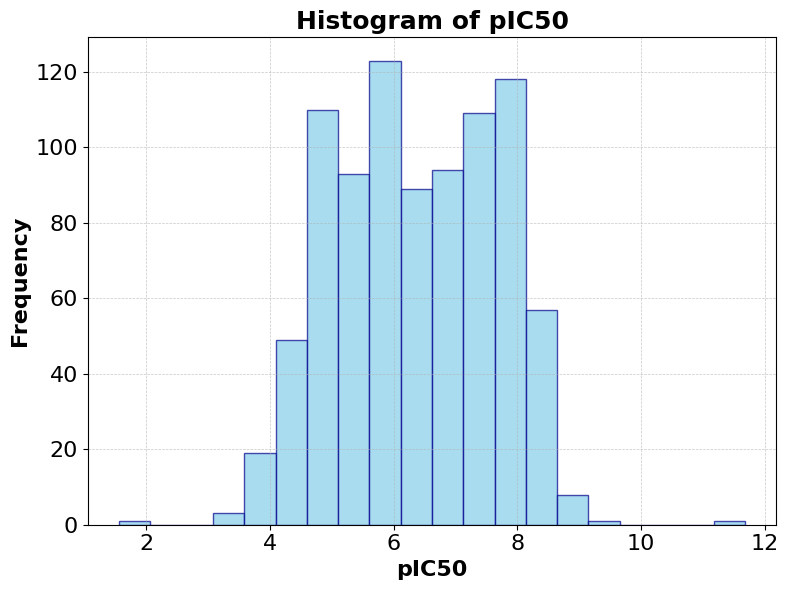

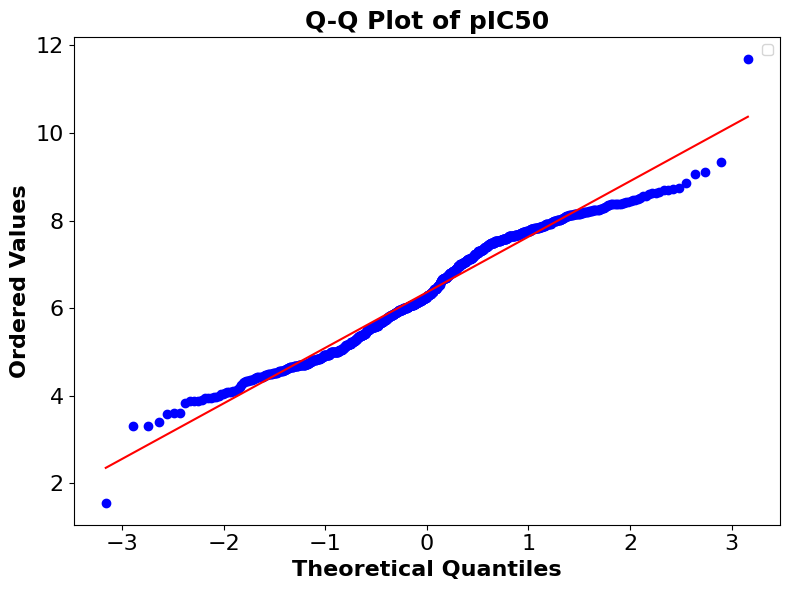

In [34]:
import matplotlib.pyplot as plt
from scipy import stats

# Sample data for log_target, replace this with your actual data
log_target = combined_bd_chmbl_unique['pIC50 Value']

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(log_target, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of pIC50', fontsize=18, weight='bold')
plt.xlabel('pIC50', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the histogram plot
plt.show()

# Q-Q plot of original data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(log_target, dist="norm", plot=plt)

# Add title and legend
plt.title('Q-Q Plot of pIC50', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()


In [35]:
# Shapiro-Wilk test
shapiro_stat, shapiro_p_value = stats.shapiro(combined_bd_chmbl_unique['pIC50 Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")

Shapiro-Wilk test statistic: 0.9751014959024911
Shapiro-Wilk test p-value: 4.498218156554427e-11


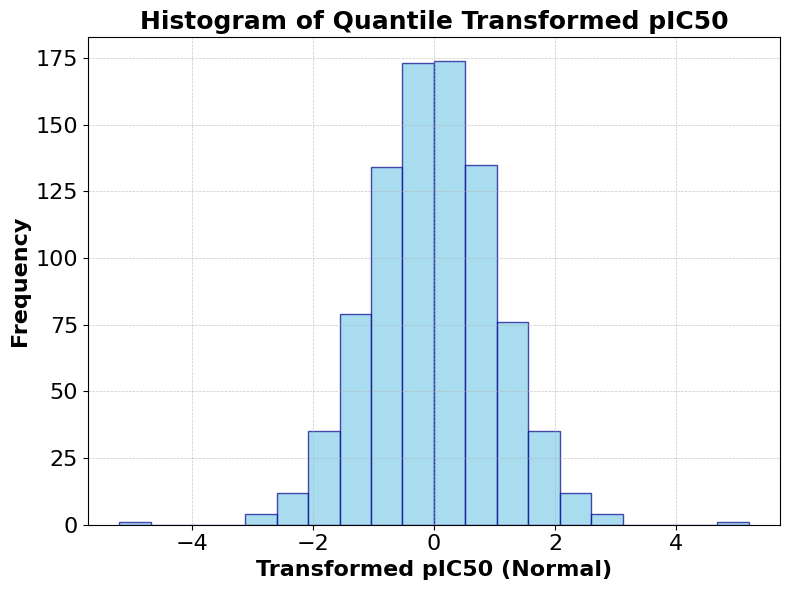

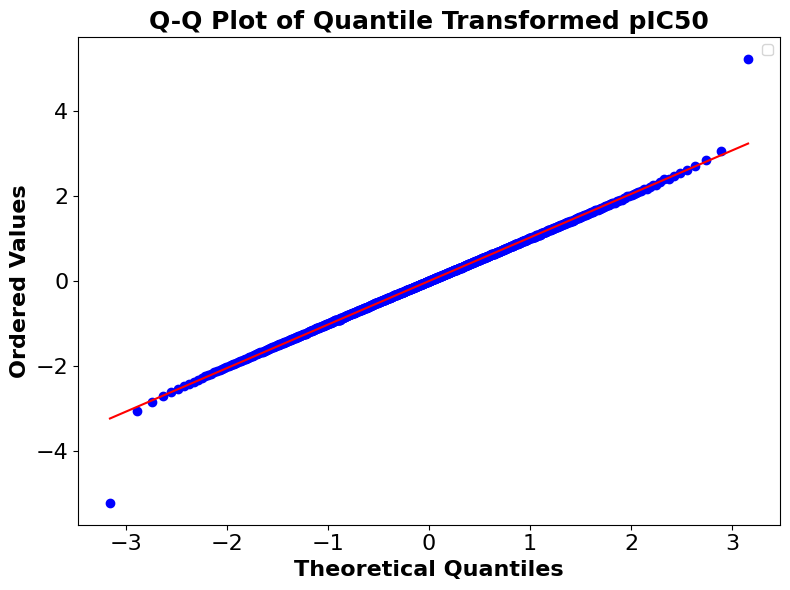

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from scipy import stats

# Extract the 'pIC50 Value' column
c_data = np.array(combined_bd_chmbl_unique['pIC50 Value']).reshape(-1, 1)

# Apply Quantile Transformation
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
c_data_transformed = quantile_transformer.fit_transform(c_data).flatten()

# Add the transformed data to the DataFrame
combined_bd_chmbl_unique['QT-pIC50 Value'] = c_data_transformed

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(c_data_transformed, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of Quantile Transformed pIC50', fontsize=18, weight='bold')
plt.xlabel('Transformed pIC50 (Normal)', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the plot
plt.show()

# Q-Q plot of transformed data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(c_data_transformed, dist="norm", plot=plt)

# Add title and legend
plt.title('Q-Q Plot of Quantile Transformed pIC50', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()


In [39]:
# Assuming combined_bd_chmbl_unique is your DataFrame that now contains the 'QT-pIC50 Value' column
shapiro_stat, shapiro_p_value = stats.shapiro(combined_bd_chmbl_unique['QT-pIC50 Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")

Shapiro-Wilk test statistic: 0.9932653547977165
Shapiro-Wilk test p-value: 0.0005518404340312449


In [40]:
# Outliers filtering:

import numpy as np
import pandas as pd

print(f"Number of rows before dropping outliers: {combined_bd_chmbl_unique.shape[0]}")

log_target = combined_bd_chmbl_unique['QT-pIC50 Value']

# Calculate Z-scores
z_scores = np.abs((log_target - log_target.mean()) / log_target.std())

# Identify outliers based on Z-score
outliers_z = z_scores > 3

# Drop outliers from the DataFrame
df_clean = combined_bd_chmbl_unique[~outliers_z]

# check the number of rows before and after dropping outliers
print(f"Number of rows after dropping outliers: {df_clean.shape[0]}")

Number of rows before dropping outliers: 875
Number of rows after dropping outliers: 873


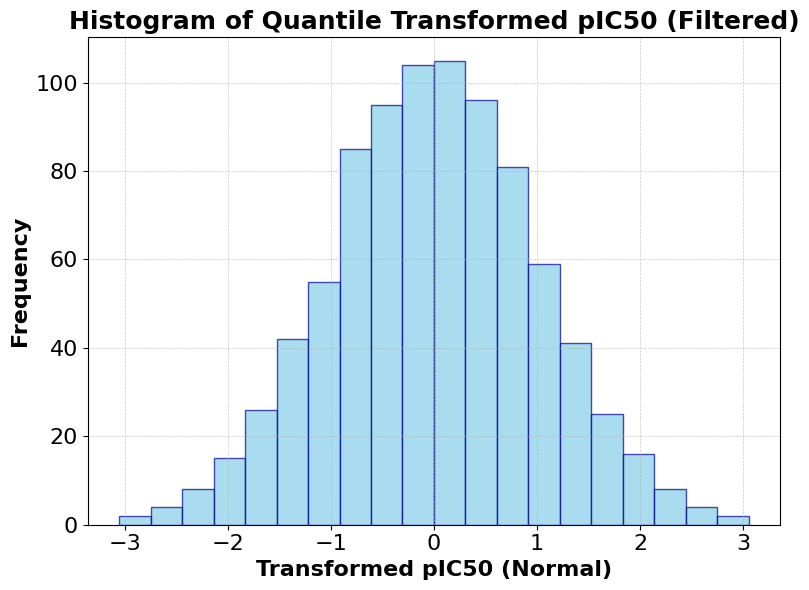

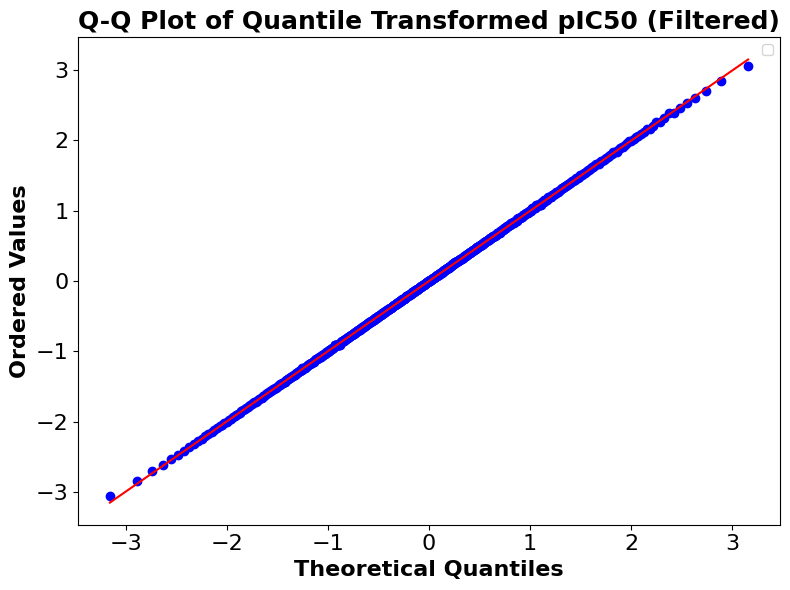

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from scipy import stats

# Sample data for log_target, replace this with your actual data
c_data_transformed = df_clean['QT-pIC50 Value']

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(c_data_transformed, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of Quantile Transformed pIC50 (Filtered)', fontsize=18, weight='bold')
plt.xlabel('Transformed pIC50 (Normal)', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the plot
plt.show()

# Q-Q plot of transformed data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(c_data_transformed, dist="norm", plot=plt)

# Add the red normality line
#plt.plot(res[0][0], res[0][0], color='red', lw=2, label='Theoretical Quantiles Line')

# Add title and legend
plt.title('Q-Q Plot of Quantile Transformed pIC50 (Filtered)', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()

In [42]:
# Shapiro-Wilk test
shapiro_stat, shapiro_p_value = stats.shapiro(df_clean['QT-pIC50 Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")


Shapiro-Wilk test statistic: 0.9996805234764119
Shapiro-Wilk test p-value: 0.9999892912127311
